# Megabenchmark Analysis (RT Evaluation)

## Overview

This Jupyter Notebook performs an analytical evaluation of **Cyclictest for Real-Time (RT)** test results.  

---

---


## Input Data Description

The benchmark generates several monitoring files in the **output directory**, each containing time-synchronized measurements from different subsystems.

| File | Description |
|------|--------------|
| `output.csv` | csv file containing test results |
| `cpu_monitor.csv` | CPU temperature, frequency, and utilization per core. |
| `cpustat_monitor.csv` | Detailed CPU statistics (user/system/idle times, context switches). |
| `irq_monitor.csv` | IRQ activity counts per CPU core over time. |
| `softirq_monitor.csv` | Kernel-level soft interrupt counts per CPU core. |
| `meminfo_monitor.csv` | Memory pressure and allocation statistics. |
| `sysinfo.json` | System configuration and metadata (CPU topology, kernel version, etc.). |

---

## Structure of `output.csv`

| Short | Explanation                                                         |
|--------|----------------------------------------------------------------------|
| `timestamp` | Timestamp of the measurement                                     |
| `T`      | Thread: Thread index and thread ID                                  |
| `P`      | Priority: RT thread priority                                        |
| `I`      | Interval: Intended wake up period for the latency measuring threads |
| `C`      | Count: Number of times the latency was measured (iteration count)   |
| `Min`    | Minimum: Minimum latency that was measured                          |
| `Act`    | Actual: Latency measured during the latest completed iteration      |
| `Avg`    | Average: Average latency that was measured                          |
| `Max`    | Maximum: Maximum latency that was measured                          |


## How can I run analysis? 

You need to specify **folder** path in the next cell and run cells below, you will get report automatically then

In [2]:
cyclictest_data_path = "06-38-03"

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import sys
import os 
import yaml
import json
from datasets import load_dataset

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.plots import *


hf_dataset = "uncledecart/rtos"

output_csv_path = f"{cyclictest_data_path}/output.csv"
cpu_monitor_path = f"{cyclictest_data_path}/cpu_monitor.csv"
irq_monitor_path = f"{cyclictest_data_path}/irq_monitor.csv"
meminfo_path = f"{cyclictest_data_path}/meminfo_monitor.csv"
sysinfo_path = f"{cyclictest_data_path}/sysinfo.json"

In [4]:
sysinfo = load_dataset(hf_dataset, data_files=sysinfo_path)['train']

sysinfo.json: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [5]:
assert sysinfo['hydra']['run']['command'][0] == 'cyclictest', "This notebook is designed to analyze cyclictest!"

In [6]:
print(f"""
Analyzing {sysinfo['hydra']['run']['command'][0]}
With isolated core(s): {sysinfo['hydra']['run']['t_core'][0]}
Cache mask: {sysinfo['hydra']['run']['llc_cache_mask'][0]}
System is stessed?: {sysinfo['hydra']['run']['stressor'][0]}
Kernel: {sysinfo['kernel']['uname'][0]}
Kernel CMD: {sysinfo['kernel']['cmdline'][0]}
""")


Analyzing cyclictest
With isolated core(s): 3
Cache mask: 0x7ff0
System is stessed?: True
Kernel: Linux zededa-rt 6.12.8-intel-ese-experimental-lts-rt #1 SMP PREEMPT_RT Thu, 28 Aug 2025 10:46:22 +0000 x86_64 GNU/Linux
Kernel CMD: BOOT_IMAGE=/vmlinuz-6.12.8-intel-ese-experimental-lts-rt root=/dev/mapper/zededa--rt--vg-root ro BOOT_IMAGE=/vmlinuz-6.12.8-intel-ese-experimental-lts-rt root=/dev/mapper/zededa--rt--vg-root ro debug=all nosplash console=ttyS0,115200 console=tty0 clocksource=tsc tsc=reliable art=virtallow no_ipi_broadcast=1 nosoftlockup efi=runtime numa_balancing=disable hugepages=1024 audit=0 nmi_watchdog=0 irqaffinity=0,1 mce=off hpet=disable rcupdate.rcu_cpu_stall_suppress=1 rcu_nocb_poll noht isolcpus=3,5,7,9 rcu_nocbs=3,5,7,9 nohz_full=3,5,7,9 intel_pstate=disable intel.max_cstate=0 intel_idle.max_cstate=0 processor.max_cstate=0 processor_idle.max_cstate=0 i915.force_probe=* i915.enable_rc6=0 i915.enable_dc=0 i915.disable_power_well=0 igb.blacklist=no console=ttyS0,11520

In [7]:
from typing import Sequence, Tuple
import re

def parse_kernel_cmdline(cmdline: str, params: Sequence[str]) -> dict[str, str]:
    results = {}

    for param in params:
        # Find all matches like param=value
        matches = re.findall(rf'\b{param}=([^ ]+)', cmdline)

        if not matches:
            print(f"{param}: not found")
            results[param] = None
        elif len(matches) == 1:
            print(f"{param}: {matches[0]}")
            results[param] = matches[0]
        else:
            print(f"WARNING: multiple occurrences of '{param}' found! Using latest value.")

            
            for value in matches:
                print(f"  -> {param}={value}")
            latest = matches[-1]
            print(f"Using latest: {param}={latest}")
            results[param] = latest

    return results

In [10]:
# check 1: selected for tests CPUs are isolated

params = parse_kernel_cmdline(str(sysinfo['kernel']['cmdline']), ["rcu_nocbs", "nohz_full", "isolcpus"])

for cpu in sysinfo['hydra']['run']['t_core'][0].split(','):
    for k, v in params.items():
        assert cpu in v, f"{k} parameter of kernel cmdline is missing CPU {cpu} which is used in tests"

  -> rcu_nocbs=3,5,7,9
  -> rcu_nocbs=1,3
Using latest: rcu_nocbs=1,3
  -> nohz_full=3,5,7,9
  -> nohz_full=1,3
Using latest: nohz_full=1,3
  -> isolcpus=3,5,7,9
  -> isolcpus=1,3
Using latest: isolcpus=1,3


In [11]:
# check 2 p-state and c-state are disabled

params = parse_kernel_cmdline(str(sysinfo['kernel']['cmdline']), ["intel_pstate", "intel.max_cstate", "intel_idle.max_cstate", "processor.max_cstate", "processor_idle.max_cstate"])

assert params["intel_pstate"] == "disable", "Intel p-state must be disabled"
assert params["intel.max_cstate"] == "0", "Intel c-state must be disabled"
assert params["intel_idle.max_cstate"] == "0", "Intel c-state must be disabled"
assert params["processor.max_cstate"] == "0", "Intel c-state must be disabled"
assert params["processor_idle.max_cstate"] == "0", "Intel c-state must be disabled"

  -> intel_pstate=disable
  -> intel_pstate=disable
Using latest: intel_pstate=disable
  -> intel.max_cstate=0
  -> intel.max_cstate=0
Using latest: intel.max_cstate=0
  -> intel_idle.max_cstate=0
  -> intel_idle.max_cstate=0
Using latest: intel_idle.max_cstate=0
  -> processor.max_cstate=0
  -> processor.max_cstate=0
Using latest: processor.max_cstate=0
  -> processor_idle.max_cstate=0
  -> processor_idle.max_cstate=0
Using latest: processor_idle.max_cstate=0


In [12]:
# check 3: hypter-threading is disabled

assert " noht " in str(sysinfo['kernel']['cmdline'])

Generating train split: 0 examples [00:00, ? examples/s]

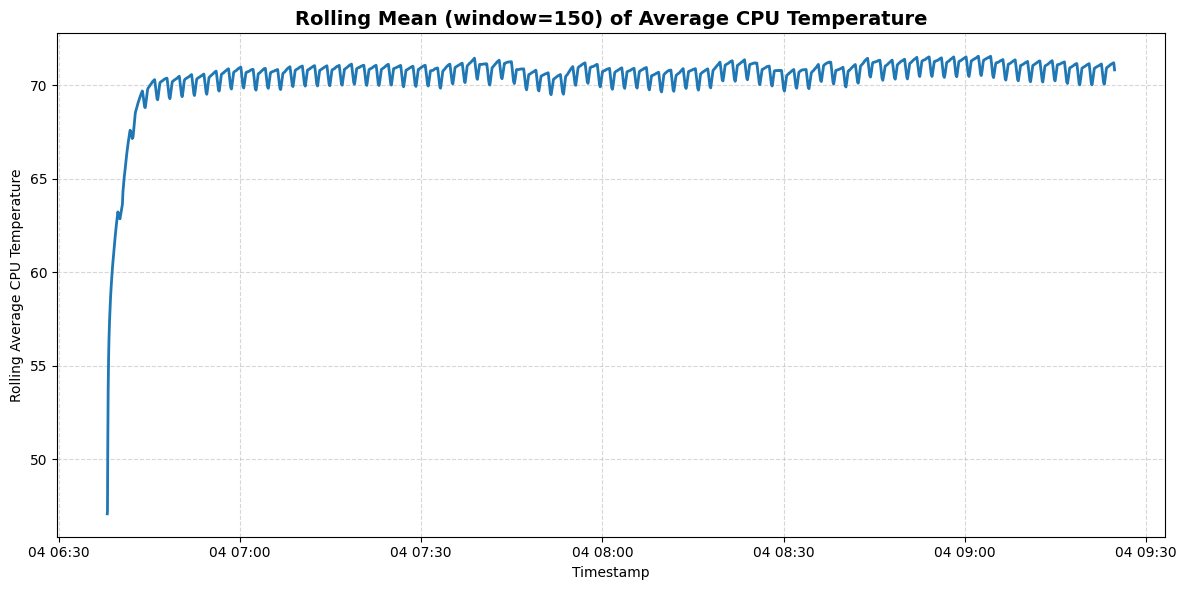

In [13]:
heat_threshold = 90
cpu_monitor_df = load_dataset("uncledecart/rtos", data_files=cpu_monitor_path)['train'].to_pandas()


### Check 1: Packages do not exceed threshold

packages = [col for col in cpu_monitor_df.columns if col.startswith("Package id")]

for pkg in packages:
    assert cpu_monitor_df[pkg].max() <= heat_threshold

### Check 2: CPUs do not exceed threshold

cpus = [col for col in cpu_monitor_df.columns if col.startswith("CPU")]

for cpu in cpus:
    assert cpu_monitor_df[cpu].max() <= heat_threshold

### Check 3: plot average temperature

plot_avg_cpu_temp(cpu_monitor_df)

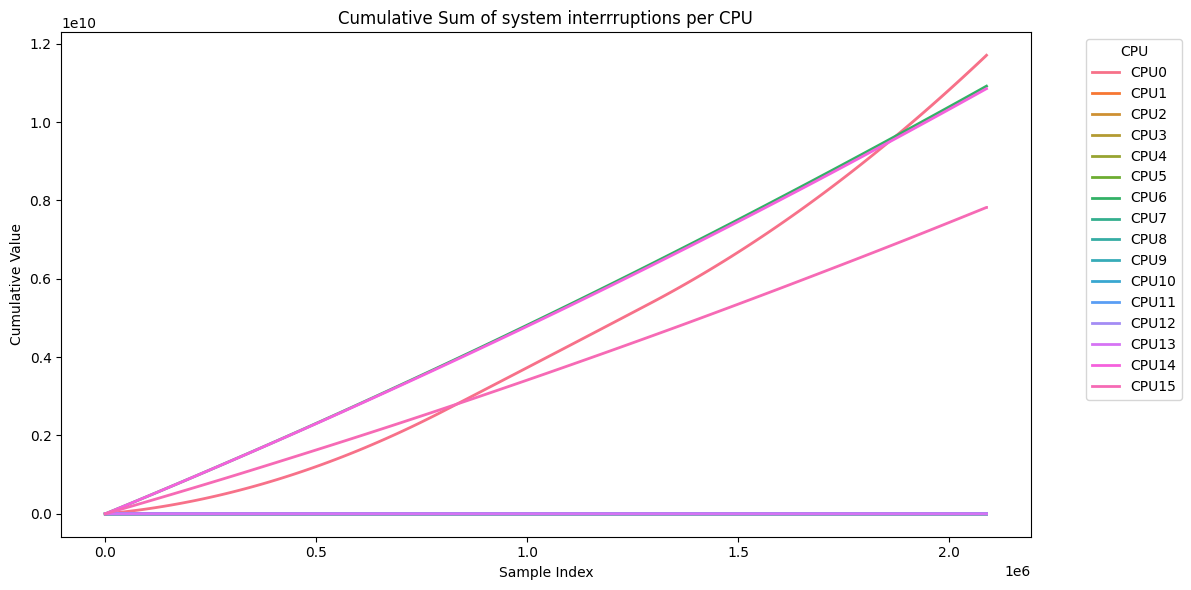

In [15]:
irq_monitor_df = load_dataset("uncledecart/rtos", data_files=irq_monitor_path)['train'].to_pandas()
mask = irq_monitor_df['description'].str.contains('APIC|MSIX', case=False, regex=True, na=False)
global_irqs = irq_monitor_df[mask]

for cpu in sysinfo['hydra']['run']['t_core'][0].split(','):
    assert global_irqs[f'CPU{cpu}'].sum() == 0

## Bonus check: plot cumsum of CPU interrupts for each CPU

cpu_cols = [col for col in irq_monitor_df.columns if col.startswith('CPU')]
cpu_df = global_irqs[cpu_cols]
cpu_cumsum_df = cpu_df.cumsum()

cpu_long_df = cpu_cumsum_df.reset_index().melt(id_vars='index', var_name='CPU', value_name='Cumulative Value')

# Plot with seaborn
plt.figure(figsize=(12, 6))
sns.lineplot(data=cpu_long_df, x='index', y='Cumulative Value', hue='CPU', linewidth=2)

plt.title('Cumulative Sum of system interrruptions per CPU')
plt.xlabel('Sample Index')
plt.ylabel('Cumulative Value')
plt.legend(title='CPU', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Generating train split: 0 examples [00:00, ? examples/s]

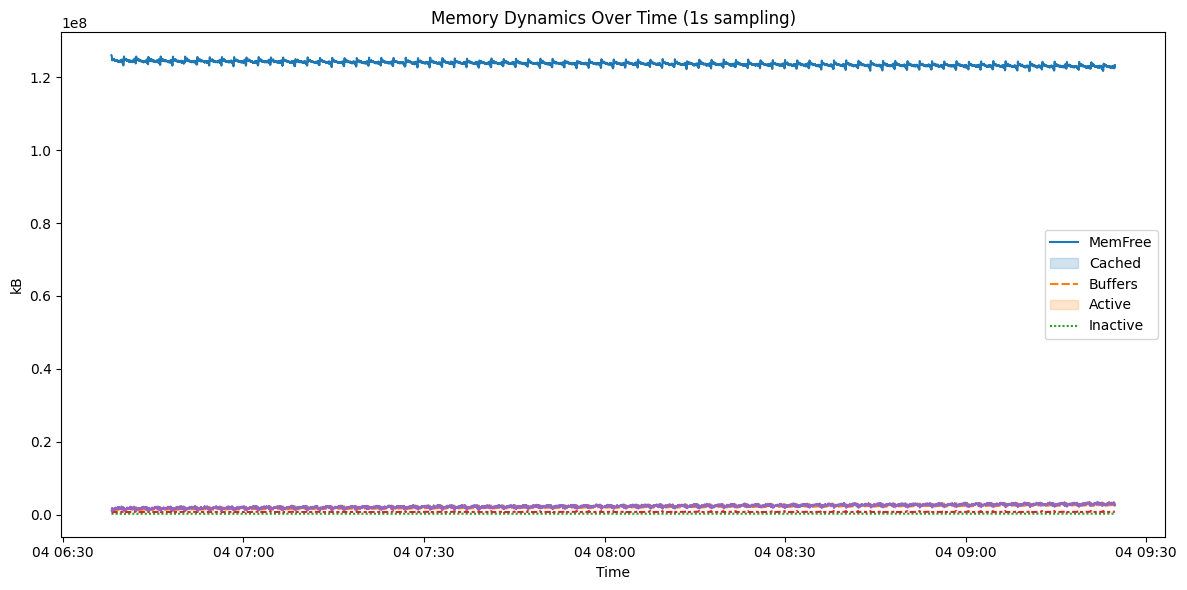

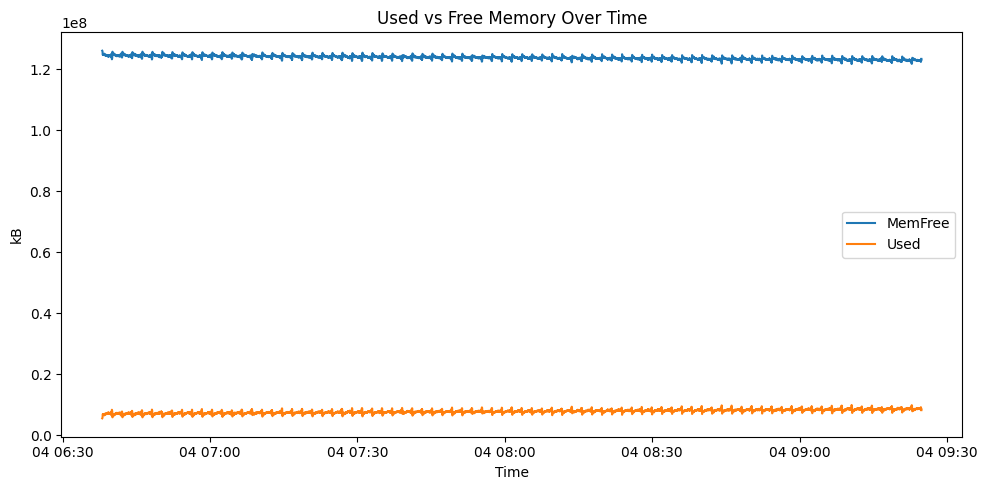

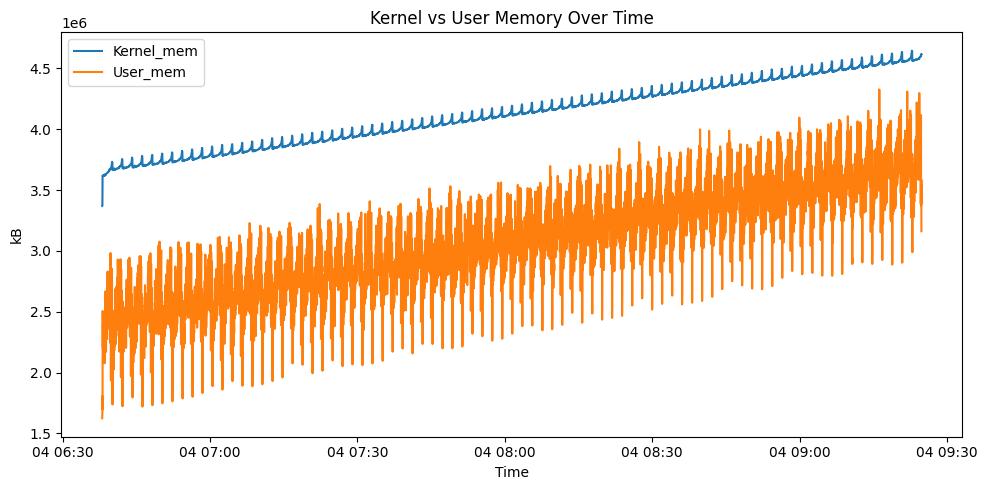

/Users/pabramov/dev/rt-tools/src/plots.py:290: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stds.values, y=stds.index, palette="crest")


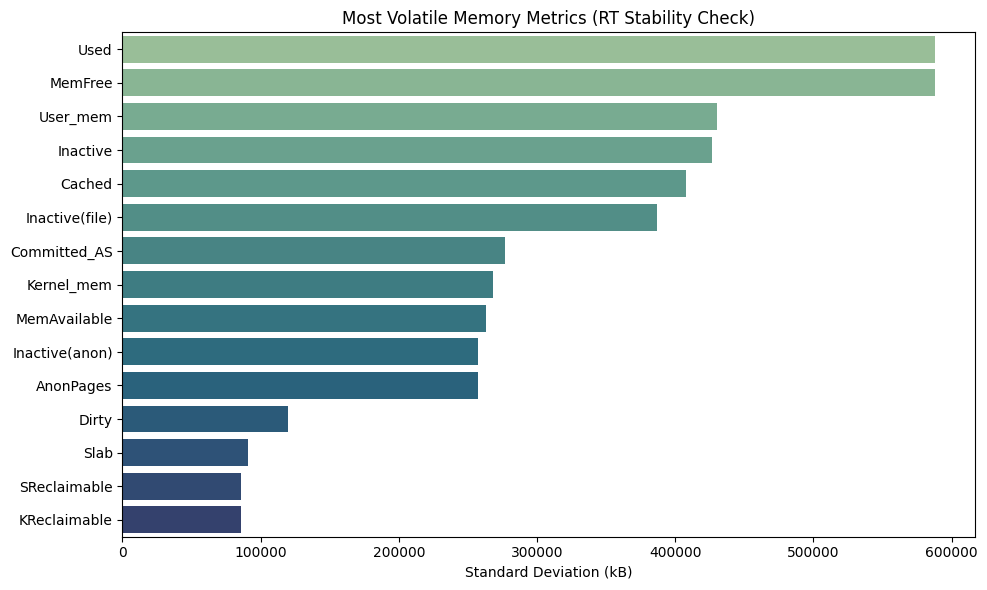

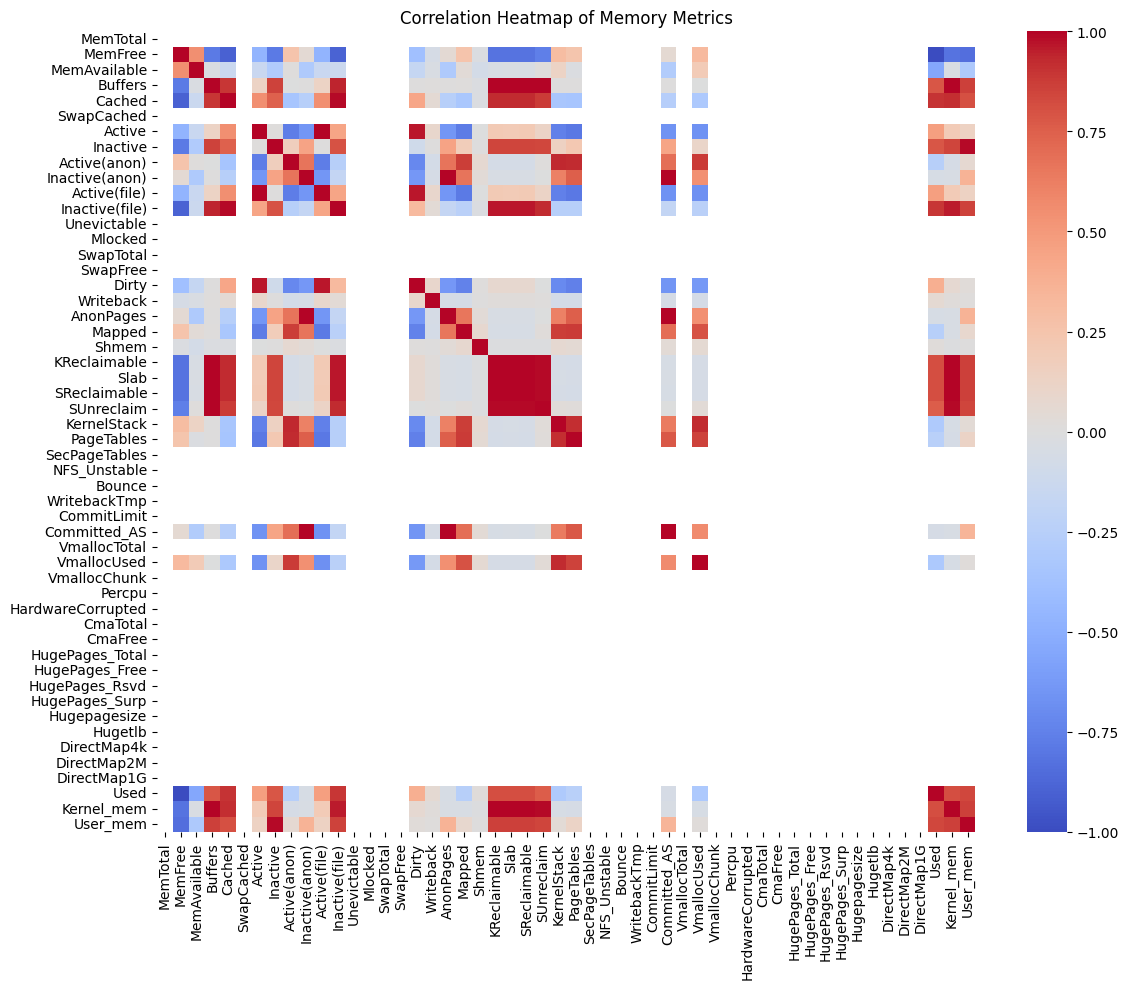

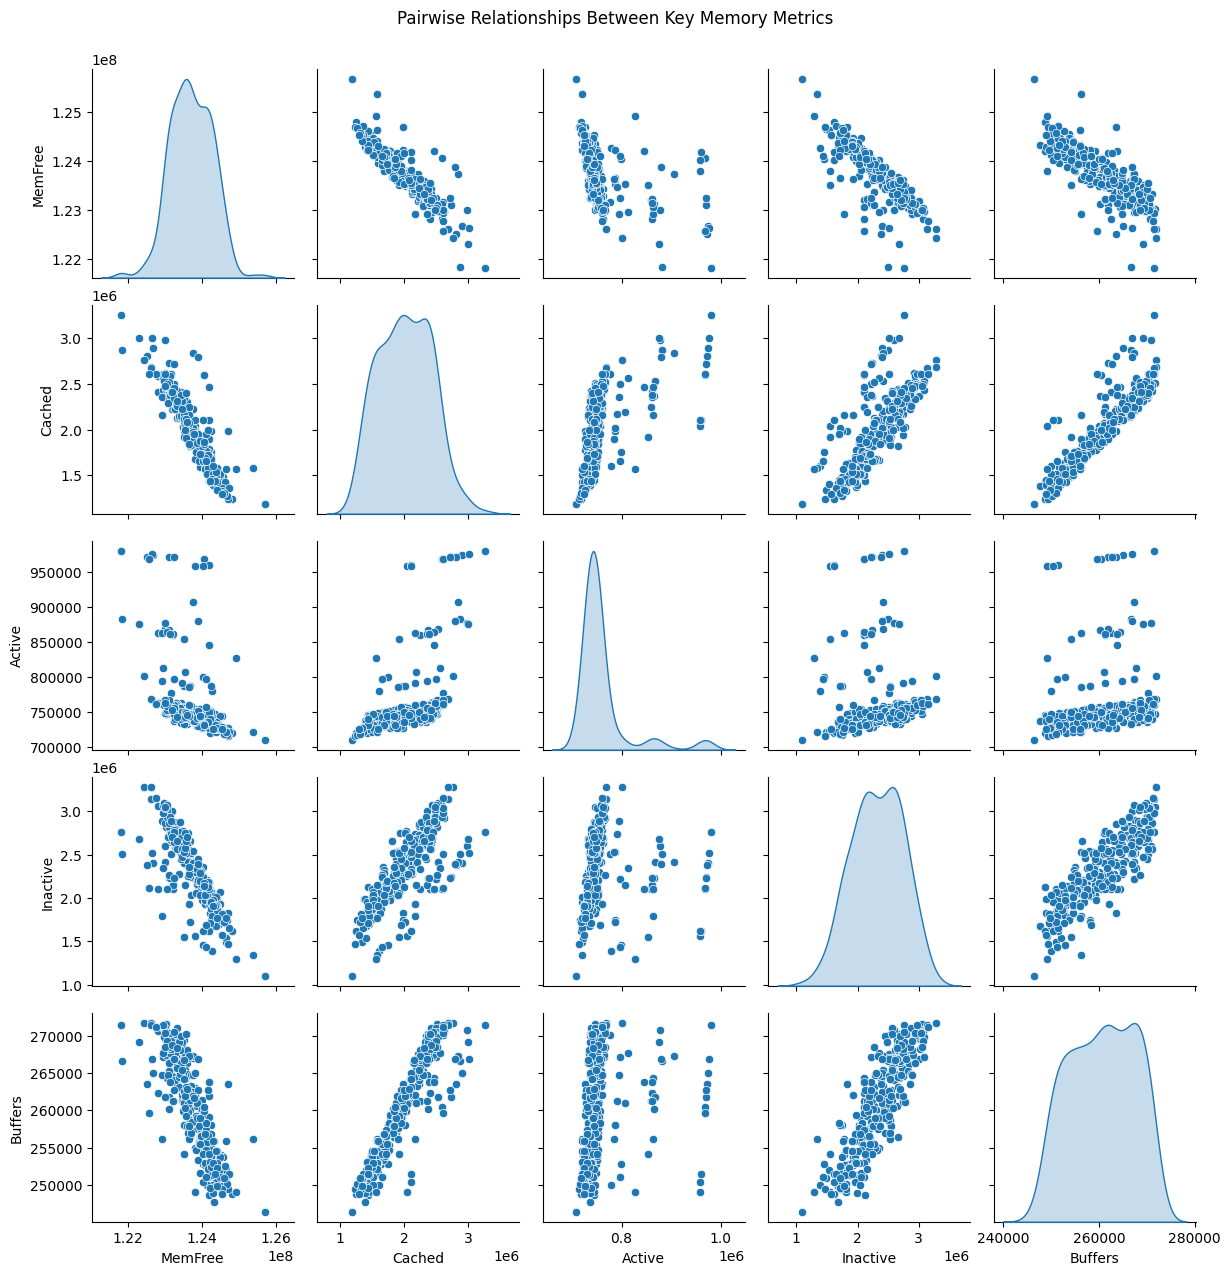

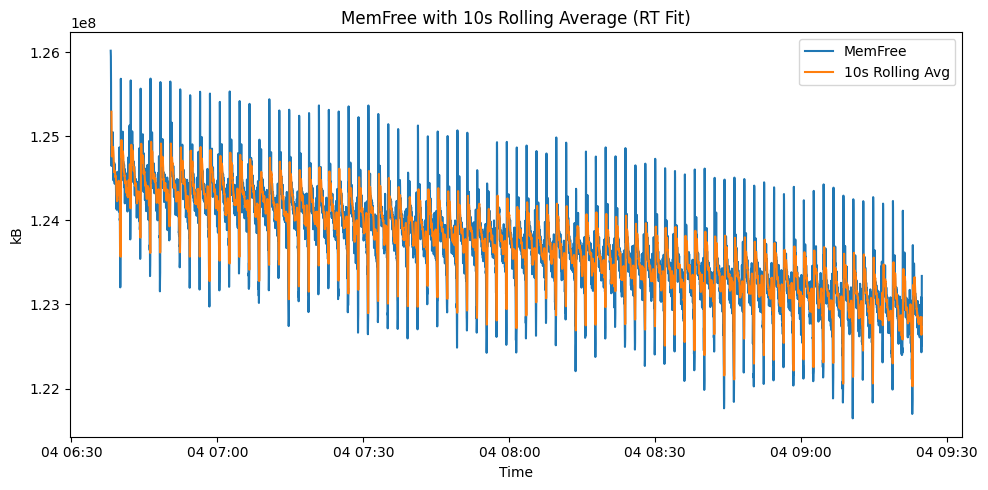

In [16]:
meminfo_monitor_df = load_dataset("uncledecart/rtos", data_files=meminfo_path)['train'].to_pandas()
plot_meminfo(meminfo_monitor_df)

## Analysing test results

In [17]:
df = load_dataset("uncledecart/rtos", data_files=output_csv_path)['train'].to_pandas()

df.tail(len(df['T'].unique()))

Generating train split: 0 examples [00:00, ? examples/s]

,timestamp,T,T_ID,P,I,C,Min,Act,Avg,Max
3970580,2025-11-04 09:24:46,0,8,99,100000,100000,2,2,3,21
3970581,2025-11-04 09:24:46,1,9,99,100001,99999,2,3,3,20
3970582,2025-11-04 09:24:46,2,10,99,100002,99998,2,2,3,18
3970583,2025-11-04 09:24:46,3,11,99,100003,99997,2,2,3,21


Analyzing 3970544 data points from column 'Max'.
------------------------------
GEV Fit Parameters:
  Shape (c):   0.7327
  Location (loc): 16.9998
  Scale (scale): 3.0377
------------------------------
Return Value at 99.9999% quantile: 21.15 CPU cycles
------------------------------


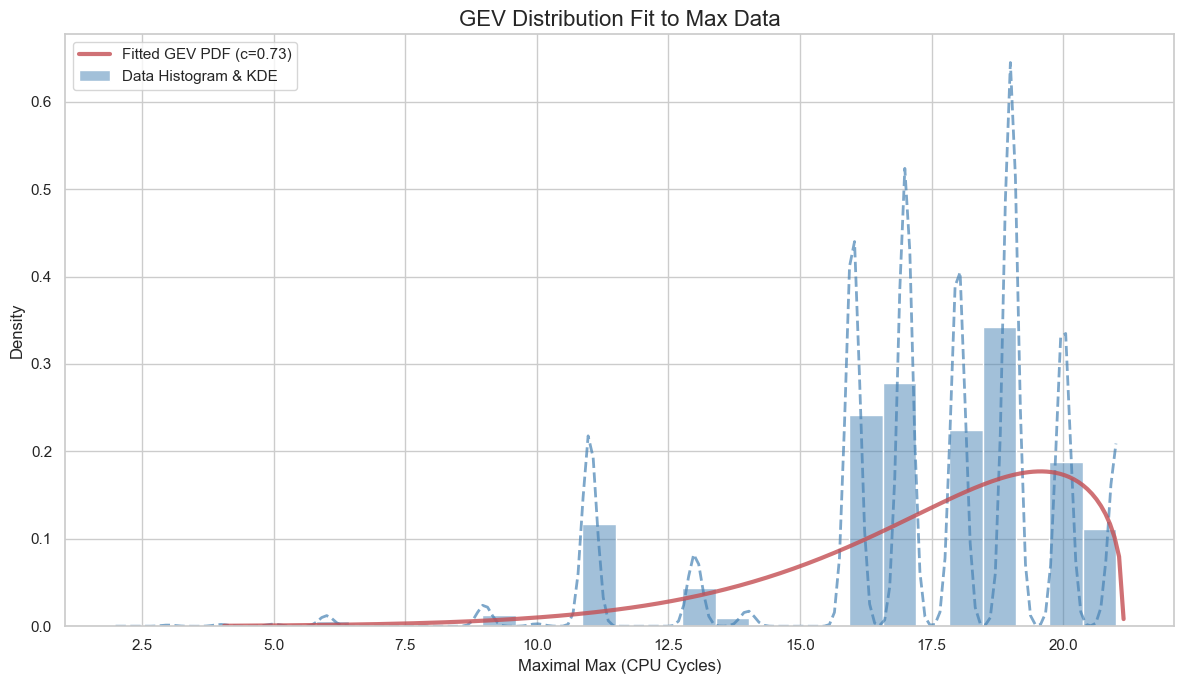

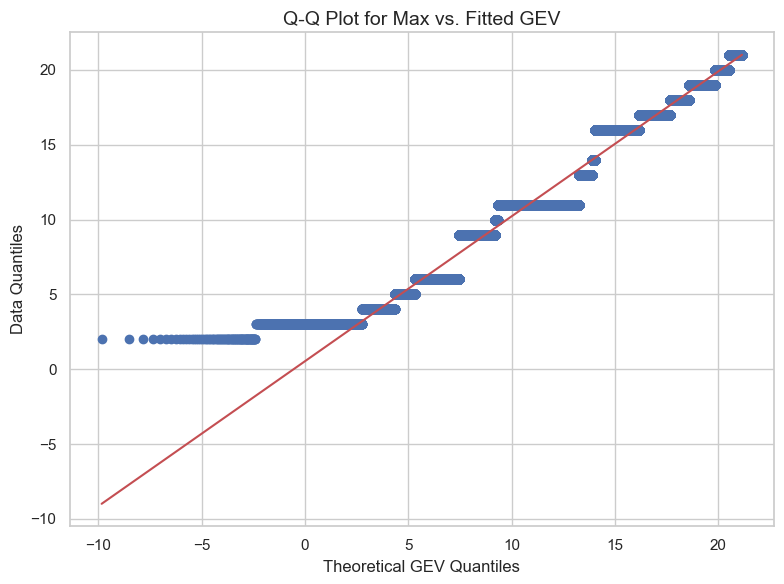

/Users/pabramov/dev/rt-tools/src/plots.py:215: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/pabramov/dev/rt-tools/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


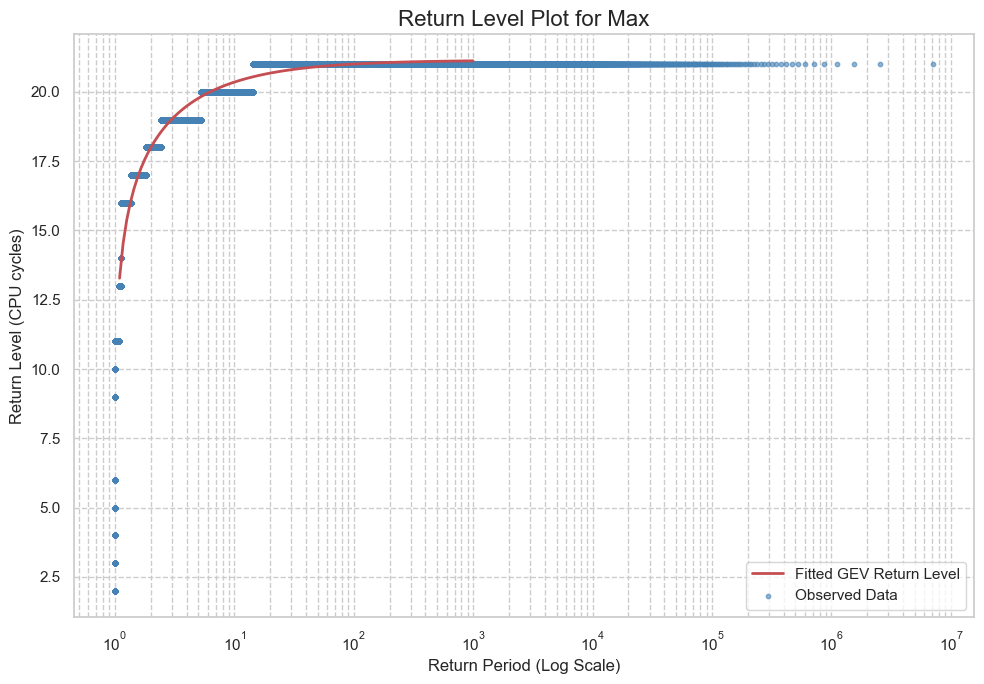

In [18]:
fit_and_plot_gev(df, "Max")

Analyzing 3970544 data points from column 'Act'.
------------------------------
GEV Fit Parameters:
  Shape (c):   0.0437
  Location (loc): 3.3035
  Scale (scale): 0.7833
------------------------------
Return Value at 99.9999% quantile: 11.43 CPU cycles
------------------------------


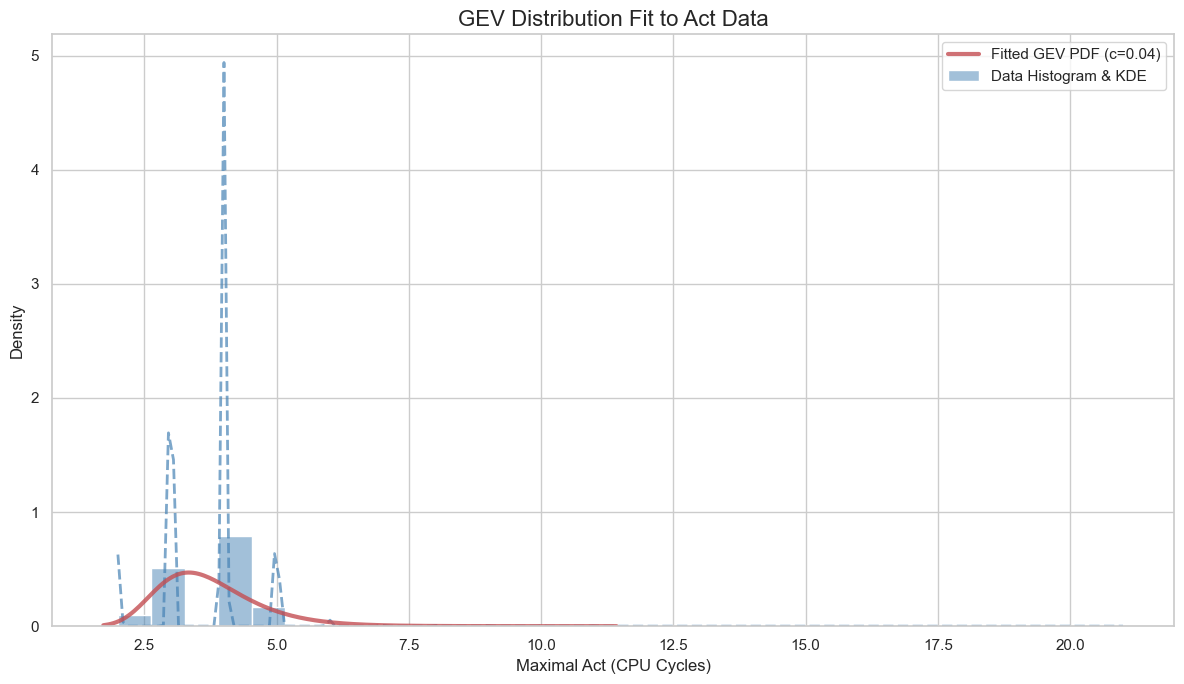

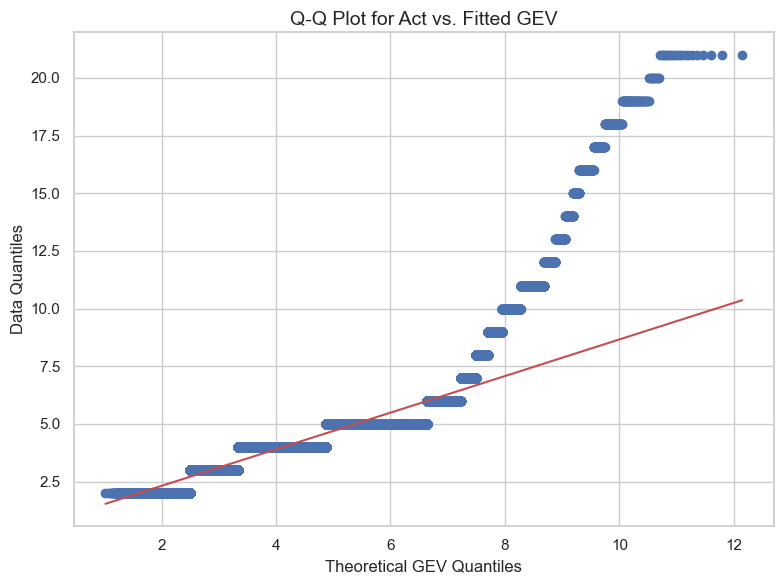

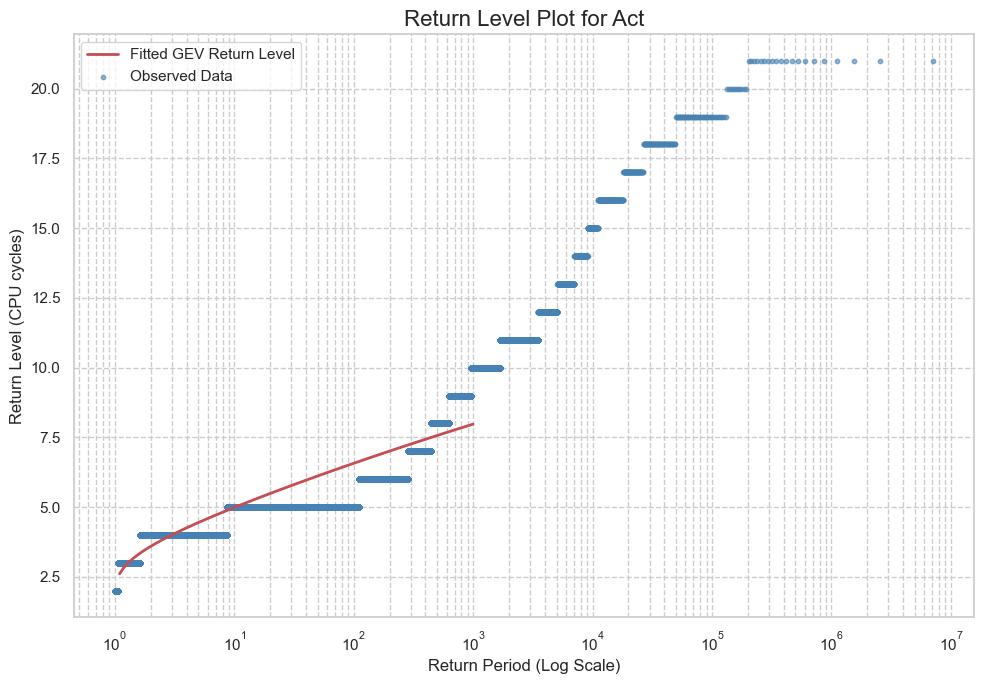

In [19]:
fit_and_plot_gev(df, "Act")